# Task 2: Face Mask Detection using Transfer Learning

## Overview
Develop Transfer Learning models to detect whether humans are wearing face masks. This task involves:
- Loading and preprocessing image datasets
- Preparing training, validation, and test data with defined image dimensions
- Developing Transfer Learning models using pre-trained networks
- Evaluating and comparing model performance

## Dataset
- **File**: `data/Face_mask_detection.zip`
- **Classes**: With Mask, Without Mask

## Rubric Coverage
1. Data Preprocessing (8 pts)
2. Building the Model (8 pts)
3. Model Training with Hyperparameter Experimentation (8 pts)
4. Model Evaluation (8 pts)
5. Visualization and Reporting (8 pts)

# 1. Imports and Setup

## Standard Imports

In [1]:
# Standard imports
import os
import zipfile
import numpy as np
import pandas as pd
import warnings

from lib.colab_bootstrap import reload_lib_modules

warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, 
                                     GlobalAveragePooling2D, Flatten, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50

# Sklearn imports
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from IPython.display import display, HTML


# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


## Setup local lib files
- If using Google Colab upload lib files to Colab session
- Create a helper to reload lib modules after code changes

In [2]:
# === COLAB BOOTSTRAP ===
BOOTSTRAP_URL = 'https://raw.githubusercontent.com/rlogwood/fs-ml-lib/main/colab_bootstrap.py'
import urllib.request; exec(urllib.request.urlopen(BOOTSTRAP_URL).read().decode())
# === END BOOTSTRAP ===
# to force reload after code changes use force_refresh=True
upload_lib(force_refresh=False)

Not in Colab, using local lib files


## public git repo fs-ml-lib imports after any needed colab setup
`https://github.com/rlogwood/fs-ml-lib.git`

In [3]:

# Imports6
import lib.text_util as tu
import lib.wrangler as wr
import lib.data_cleaner as dc
import lib.analyzer as da
import lib.corr_analysis as ca
import lib.utility as utl
import lib.data_downloader as ddl

# Reload modules after code changes
reload_lib_modules()

  ✓ Reloaded lib.colab_bootstrap
  ✓ Reloaded lib.text_util
  ✓ Reloaded lib.wrangler
  ✓ Reloaded lib.data_cleaner
  ✓ Reloaded lib.utility
  ✓ Reloaded lib.analyzer
  ✓ Reloaded lib.corr_analysis
  ✓ Reloaded lib.data_downloader


In [4]:
# pycharm currently has a bug that prevents mixing print and display output
# run this demo to make sure text is displaying properly in your run env
# tu.demo_text_print()

## Download any missing data files from Google Drive

In [5]:
# Unit 4 Incremental Capstone Google Drive Data Files
FOLDER_ID = "1WJUxYQNtlGy1q5EQjIjRuo2SFxVW9ivC?usp=sharing"

# Files expected to be found in Google drive data folder
# ALL_FILES = ['Churn_Modeling.csv','DENTAL_1.NPZ','Face_mask_detection.zip','GrammarandProductReviews.xlsx']
EXPECTED_FILES = ['Face_mask_detection.zip']

# colab data direcotry
DATA_DIR = ddl.get_data_dir()
ddl.ensure_data_available(FOLDER_ID, EXPECTED_FILES)

'./data'

 # 2. Data Preprocessing (Rubric Task 1: 8 pts)

**Objectives:**
- Extract the zip file
- Explore the dataset structure
- Resize images to consistent dimensions (224x224)
- Normalize pixel values [0, 1]
- Create training, validation, and test splits
- Apply data augmentation

## 2.1 Extract and Explore Dataset

In [6]:
# Extract the zip file
zip_path = f'{DATA_DIR}/Face_mask_detection.zip'
#extract_path = 'data/Face_mask_detection'
extract_path = f'{DATA_DIR}/data'

print(f"zip_path: {zip_path}")
print(f"extract_path: {extract_path}")


zip_path: ./data/Face_mask_detection.zip
extract_path: ./data/data


In [7]:

if not os.path.exists(extract_path):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('data/')
    print("Extraction complete!")
else:
    print(f"Dataset already extracted at {extract_path}")

# List contents
print("\nDataset structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = ' ' * 2 * (level + 1)
        for d in dirs:
            print(f"{subindent}{d}/")

Dataset already extracted at ./data/data

Dataset structure:
data/
  without_mask/
  with_mask/
  without_mask/
  with_mask/


In [8]:
# Find the actual data directory structure
# The zip might have different structures, let's find it
def find_image_dirs(base_path):
    """Find directories containing images."""
    image_dirs = []
    for root, dirs, files in os.walk(base_path):
        # Check if this directory contains images
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            image_dirs.append((root, len(image_files)))
    return image_dirs

image_dirs = find_image_dirs(extract_path)
print("Directories containing images:")
for dir_path, count in image_dirs:
    print(f"  {dir_path}: {count} images")

Directories containing images:
  ./data/data\without_mask: 3828 images
  ./data/data\with_mask: 3725 images


In [9]:
# Set up data directories (adjust based on actual structure)
# Common structures: train/test or with_mask/without_mask

# Try to identify the structure
base_data_dir = extract_path

# Look for train/test or direct class folders
subdirs = os.listdir(base_data_dir)
print(f"Contents of {base_data_dir}: {subdirs}")

# Check if there's a nested structure
for subdir in subdirs:
    subdir_path = os.path.join(base_data_dir, subdir)
    if os.path.isdir(subdir_path):
        contents = os.listdir(subdir_path)
        print(f"  {subdir}/: {contents[:5]}{'...' if len(contents) > 5 else ''}")

Contents of ./data/data: ['without_mask', 'with_mask']
  without_mask/: ['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']...
  with_mask/: ['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']...


In [10]:
# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

tu.print_heading("IMAGE PREPROCESSING PARAMETERS")
print(f"Image Height: {IMG_HEIGHT}")
print(f"Image Width: {IMG_WIDTH}")
print(f"Batch Size: {BATCH_SIZE}")

IMAGE PREPROCESSING PARAMETERS
Image Height: 224
Image Width: 224
Batch Size: 32


## 2.2 Create Data Generators with Augmentation

### find training data and test data directories

In [11]:
# Find the correct data directory
# Look for common patterns
possible_paths = [
    os.path.join(extract_path, 'train'),
    os.path.join(extract_path, 'Train'),
    os.path.join(extract_path, 'data', 'train'),
    extract_path
]

train_dir = None
test_dir = None

for path in possible_paths:
    if os.path.exists(path):
        # Check if it has class subdirectories
        subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
        if any('mask' in d.lower() for d in subdirs):
            train_dir = path
            print(f"Found data directory: {train_dir}")
            print(f"Classes: {subdirs}")
            break

# Also check for test directory
test_paths = [
    os.path.join(extract_path, 'test'),
    os.path.join(extract_path, 'Test'),
    os.path.join(extract_path, 'data', 'test'),
]

for path in test_paths:
    if os.path.exists(path):
        test_dir = path
        print(f"Found test directory: {test_dir}")
        break


if train_dir is None:
    error_msg = """
    Could not find standard directory structure.
    Please check the extracted contents and set train_dir manually."
    """
    raise Exception(error_msg)



Found data directory: ./data/data
Classes: ['without_mask', 'with_mask']


### create the data image generator

In [17]:
from textwrap import dedent

def create_train_datagen(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2,
    verbose=True
):
    """Create an ImageDataGenerator with augmentation for training."""

    datagen = ImageDataGenerator(
        rescale=rescale,
        rotation_range=rotation_range,
        width_shift_range=width_shift_range,
        height_shift_range=height_shift_range,
        shear_range=shear_range,
        zoom_range=zoom_range,
        horizontal_flip=horizontal_flip,
        fill_mode=fill_mode,
        validation_split=validation_split
    )

    if verbose:
        tu.print_heading("DATA AUGMENTATION CONFIGURATION")
        print(dedent(f"""\
            Training Augmentation:
              - Rescale: {rescale} (normalize to [0,1])
              - Rotation: +/- {rotation_range} degrees
              - Width/Height Shift: {int(width_shift_range * 100)}%
              - Shear Range: {shear_range}
              - Zoom Range: {zoom_range}
              - Horizontal Flip: {'Yes' if horizontal_flip else 'No'}
              - Fill Mode: {fill_mode}
              - Validation Split: {int(validation_split * 100)}%
        """))

    return datagen


train_datagen = create_train_datagen()


DATA AUGMENTATION CONFIGURATION
Training Augmentation:
  - Rescale: 0.00392156862745098 (normalize to [0,1])
  - Rotation: +/- 20 degrees
  - Width/Height Shift: 20%
  - Shear Range: 0.2
  - Zoom Range: 0.2
  - Horizontal Flip: Yes
  - Fill Mode: nearest
  - Validation Split: 20%



### Uses the train_datagen (with augmentation)
- flow_from_directory - Loads images from train_dir subdirectories (each subdirectory = one class)
- target_size - Resizes all images to consistent size
- class_mode='binary' - Binary classification (2 classes: mask/no-mask)
- subset='training' - Uses 80% of data (due to validation_split=0.2 above)
- shuffle=True - Randomizes order each epoch

In [18]:
# Create data generators
# Use the training directory with validation split

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 6043 images belonging to 2 classes.


### Validation Generator
- Same directory as training, but subset='validation' gets the other 20%
- No shuffle - consistent validation results
- Same augmentation settings (but augmentation is typically only applied during training iterations)

In [19]:

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1510 images belonging to 2 classes.


### Test Generator
- Creates new generator without augmentation (only rescaling)
- If separate test directory exists, uses it
- Fallback: If no test dir, reuses validation data as test

In [20]:
# Test generator (if test directory exists)
test_datagen = ImageDataGenerator(rescale=1./255)
if test_dir:
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
else:
    # Use validation as test
    test_generator = validation_generator
    print("Note: Using validation data as test data")

Note: Using validation data as test data


### Summary of Data Generators
- Train/Val split from same directory using subset parameter
- Augmentation only for training, not validation/test
- Graceful fallback if test directory doesn't exist
- Binary classification setup for 2-class problem

In [21]:
print(f"\nClass indices: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")


Class indices: {'with_mask': 0, 'without_mask': 1}
Training samples: 6043
Validation samples: 1510


### Visualize Sample Images

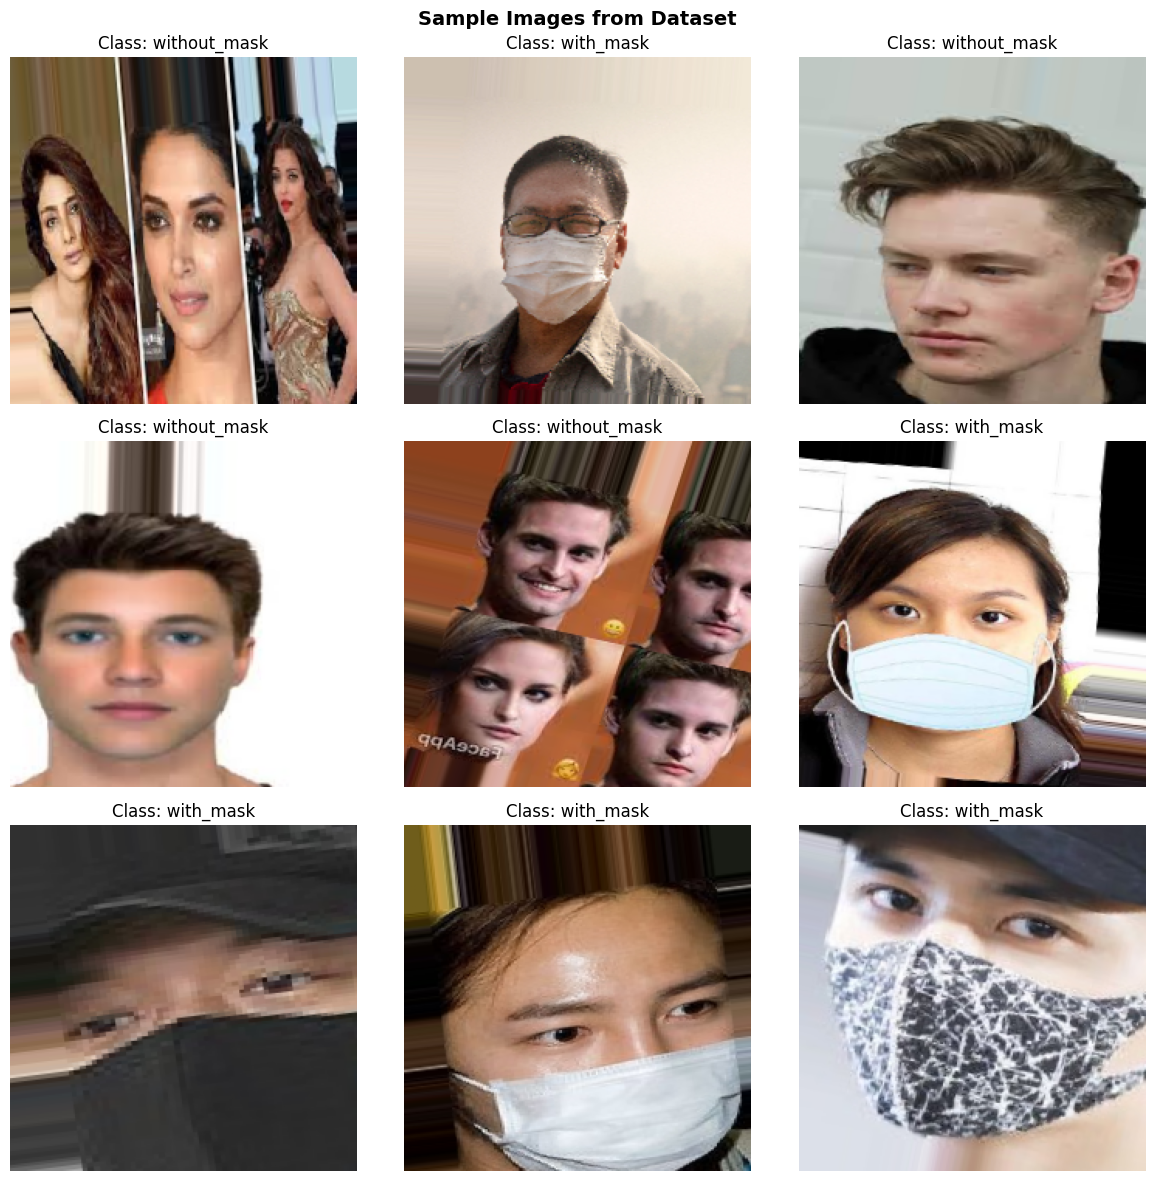

In [22]:
# Visualize sample images from dataset
def visualize_samples(generator, n_samples=9):
    """Visualize sample images from generator."""
    class_names = list(generator.class_indices.keys())
    
    # Get a batch
    images, labels = next(generator)
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            label_idx = int(labels[i])
            ax.set_title(f'Class: {class_names[label_idx]}', fontsize=12)
            ax.axis('off')
    
    plt.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples(train_generator)

## 2.3 Preprocessing Summary

**Data Preprocessing Complete:**
- Extracted zip file and explored structure
- Images resized to 224x224 pixels
- Pixel values normalized to [0, 1]
- Data augmentation applied (rotation, shift, flip, zoom)
- Train/Validation split: 80%/20%
- Class: Binary (With Mask / Without Mask)

---
# 3. Building Transfer Learning Models (Rubric Task 2: 8 pts)

**Models to build:**
1. VGG16 (pre-trained on ImageNet)
2. MobileNetV2 (lightweight, efficient)

**Architecture components:**
- Pre-trained base (frozen initially)
- GlobalAveragePooling2D
- Dense layers with Dropout
- Softmax/Sigmoid output

### Build transfer learning model for binary classification

In [ ]:
def build_transfer_model(base_model_name='VGG16', input_shape=(224, 224, 3), 
                         learning_rate=0.001, fine_tune=False):
    """
    Build a Transfer Learning model for binary classification.
    
    Parameters:
    - base_model_name: 'VGG16', 'MobileNetV2', or 'ResNet50'
    - input_shape: Input image shape
    - learning_rate: Learning rate for optimizer
    - fine_tune: Whether to unfreeze some base layers
    
    Returns:
    - Compiled Keras model
    """
    
    # Load pre-trained base model
    if base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Unknown model: {base_model_name}")
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Custom classification head for model
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x) # Reduces spatial dimensions
    x = Dense(256, activation='relu')(x) # First dense layer
    x = BatchNormalization()(x) # Normalizes activations during training
    x = Dropout(0.5)(x) # Prevent overfitting (50% dropout)
    x = Dense(128, activation='relu')(x) # Second dense layer
    x = Dropout(0.3)(x) # More dropout (30%)
    outputs = Dense(1, activation='sigmoid')(x) # Binary output [0,1]

    # Build model
    model = Model(inputs, outputs, name=f'{base_model_name}_TransferLearning')
    
    # Optionally fine-tune some layers
    if fine_tune:
        # Unfreeze the last few layers of base model
        base_model.trainable = True
        # Allows train the last 20 layers of the base model for task-specific adaptation
        for layer in base_model.layers[:-20]:  # Freeze all but last 20 layers
            layer.trainable = False
    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model

### define model constants

In [28]:
EPOCHS = 20

### build VGG16 model

In [ ]:
# Build VGG16 model
tu.print_heading("BUILDING VGG16 TRANSFER LEARNING MODEL")

vgg16_model, vgg16_base = build_transfer_model(
    base_model_name='VGG16',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    learning_rate=0.001
)

vgg16_model.summary()

### build MobileNetV2 model

In [ ]:
# Build MobileNetV2 model
tu.print_heading("BUILDING MobileNetV2 TRANSFER LEARNING MODEL")

mobilenet_model, mobilenet_base = build_transfer_model(
    base_model_name='MobileNetV2',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    learning_rate=0.001
)

mobilenet_model.summary()

### model overview

In [25]:
# Model architecture explanation
tu.print_heading("TRANSFER LEARNING ARCHITECTURE DESIGN")
print(f"""
{tu.bold_text("1. BASE MODEL (Pre-trained on ImageNet):")}
   - VGG16: Classic architecture, 16 layers, larger model
   - MobileNetV2: Efficient, lightweight, good for mobile deployment
   - Weights frozen initially (feature extraction mode)

{tu.bold_text("2. CUSTOM CLASSIFICATION HEAD:")}
   - GlobalAveragePooling2D: Reduces spatial dimensions
   - Dense(256) + ReLU: Feature transformation
   - BatchNormalization: Stabilizes training
   - Dropout(0.5): Prevents overfitting
   - Dense(128) + ReLU: Further feature learning
   - Dropout(0.3): Additional regularization
   - Dense(1) + Sigmoid: Binary classification output

{tu.bold_text("3. REGULARIZATION TECHNIQUES:")}
   - Dropout layers (0.5, 0.3)
   - BatchNormalization
   - Data augmentation (applied during training)
""")

TRANSFER LEARNING ARCHITECTURE DESIGN

1. BASE MODEL (Pre-trained on ImageNet):
   - VGG16: Classic architecture, 16 layers, larger model
   - MobileNetV2: Efficient, lightweight, good for mobile deployment
   - Weights frozen initially (feature extraction mode)

2. CUSTOM CLASSIFICATION HEAD:
   - GlobalAveragePooling2D: Reduces spatial dimensions
   - Dense(256) + ReLU: Feature transformation
   - BatchNormalization: Stabilizes training
   - Dropout(0.5): Prevents overfitting
   - Dense(128) + ReLU: Further feature learning
   - Dropout(0.3): Additional regularization
   - Dense(1) + Sigmoid: Binary classification output

3. REGULARIZATION TECHNIQUES:
   - Dropout layers (0.5, 0.3)
   - BatchNormalization
   - Data augmentation (applied during training)



---
# 4. Model Training with Hyperparameter Experimentation (Rubric Task 3: 8 pts)

**Experiments:**
1. Compare VGG16 vs MobileNetV2
2. Different learning rates
3. Fine-tuning vs feature extraction

In [ ]:
# Define callbacks
def get_callbacks(model_name):
    """Return callbacks for training."""
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]
    return callbacks

### model training

In [26]:
# Calculate steps
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

tu.print_sub_heading("Calculating Steps per Epoch and Validation Steps")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

Calculating Steps per Epoch and Validation Steps
Steps per epoch: 188
Validation steps: 47


#### train VGG16 model

In [ ]:
# Train VGG16 model
tu.print_heading("TRAINING VGG16 MODEL")

vgg16_history = vgg16_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=get_callbacks('VGG16'),
    verbose=1
)
print(tu.bold_text("VGG16 training complete!"))

#### train MobileNetV2 model

In [ ]:
# Train MobileNetV2 model
tu.print_heading("TRAINING MobileNetV2 MODEL")

mobilenet_history = mobilenet_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=get_callbacks('MobileNetV2'),
    verbose=1
)
print(tu.bold_text("MobileNetV2 training complete!"))

#### fine tuning MobileNetV2 model

In [ ]:
# Experiment with fine-tuning MobileNetV2
tu.print_heading("FINE-TUNING MobileNetV2 MODEL")

# Build fine-tuned model
mobilenet_ft_model, mobilenet_ft_base = build_transfer_model(
    base_model_name='MobileNetV2',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    learning_rate=0.0001,  # Lower learning rate for fine-tuning
    fine_tune=True
)

mobilenet_ft_history = mobilenet_ft_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=get_callbacks('MobileNetV2_FineTune'),
    verbose=1
)
print(tu.bold_text("Fine-tuned MobileNetV2 training complete!"))

---
# 5. Model Evaluation (Rubric Task 4: 8 pts)

**Evaluation:**
- Compare all models on test data
- Confusion matrices
- Classification reports
- Discuss which model performs best and why

In [ ]:
# Evaluate all models
def evaluate_model(model, generator, model_name):
    """Evaluate a model and return metrics."""
    # Reset generator
    generator.reset()
    
    # Get predictions
    predictions = model.predict(generator, verbose=0)
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_true = generator.classes
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=list(generator.class_indices.keys()))
    
    print(f"\n{model_name} Evaluation")
    print("="*60)
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nClassification Report:")
    print(report)
    
    return {
        'name': model_name,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'predictions': predictions,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [ ]:
# Evaluate all models
results = {}

results['VGG16'] = evaluate_model(vgg16_model, test_generator, 'VGG16')
results['MobileNetV2'] = evaluate_model(mobilenet_model, test_generator, 'MobileNetV2')
results['MobileNetV2_FineTune'] = evaluate_model(mobilenet_ft_model, test_generator, 'MobileNetV2 (Fine-Tuned)')

In [ ]:
# Compare models
tu.print_heading("MODEL COMPARISON SUMMARY")

print(f"{'Model':<25} {'Accuracy':<15}")

best_model = None
best_acc = 0

for name, res in results.items():
    print(f"{res['name']:<25} {res['accuracy']:.4f}")
    if res['accuracy'] > best_acc:
        best_acc = res['accuracy']
        best_model = name

print("-"*40)
print(f"\nBest Model: {best_model} (Accuracy: {best_acc:.4f})")

In [ ]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = list(test_generator.class_indices.keys())

for idx, (name, res) in enumerate(results.items()):
    sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[idx])
    axes[idx].set_title(f"{res['name']}\nAccuracy: {res['accuracy']:.4f}", fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

tu.print_heading("Confusion matrices")
plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Discussion of metrics and model selection
tu.print_heading("METRICS DISCUSSION FOR FACE MASK DETECTION")

print(f"""
{tu.print_heading("IMPORTANT METRICS FOR THIS TASK:")}

{tu.bold_text("1. RECALL for 'Without Mask' class - CRITICAL")}
   - Missing someone without a mask (False Negative) is dangerous
   - In safety applications, we must catch all violations
   
{tu.bold_text("2. PRECISION for 'Without Mask' class")}
   - False alarms (predicting no mask when mask is worn) cause inconvenience
   - Balance needed based on deployment context

{tu.bold_text("3. OVERALL ACCURACY")}
   - Good general measure but can be misleading with class imbalance

{tu.bold_and_colored_text("MODEL SELECTION CONSIDERATIONS:",tu.Color.ORANGE)}

- VGG16: Higher accuracy potential but slower, more memory
- MobileNetV2: Faster, lighter, good for real-time applications
- Fine-tuning: Can improve accuracy but requires careful learning rate

{tu.bold_and_colored_text("HYPERPARAMETER EFFECTS:",tu.Color.ORANGE)}

- Learning Rate: Lower rates (0.0001) work better for fine-tuning
- Batch Size: Larger batches provide more stable gradients
- Data Augmentation: Critical for preventing overfitting on small datasets
- Dropout: Higher rates (0.5) help with transfer learning
""")

# 6. Visualization and Reporting (Rubric Task 5: 8 pts)

**Visualizations:**
1. Training history curves
2. Sample predictions with confidence scores
3. Model comparison charts
4. Final summary report

In [ ]:
# Plot training histories
def plot_training_history(histories, names):
    """Plot training histories for multiple models."""
    fig, axes = plt.subplots(2, len(histories), figsize=(6*len(histories), 10))
    
    if len(histories) == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (history, name) in enumerate(zip(histories, names)):
        # Accuracy
        axes[0, idx].plot(history.history['accuracy'], label='Train', color='blue')
        axes[0, idx].plot(history.history['val_accuracy'], label='Validation', color='orange')
        axes[0, idx].set_title(f'{name} - Accuracy', fontweight='bold')
        axes[0, idx].set_xlabel('Epoch')
        axes[0, idx].set_ylabel('Accuracy')
        axes[0, idx].legend()
        axes[0, idx].grid(True, alpha=0.3)
        
        # Loss
        axes[1, idx].plot(history.history['loss'], label='Train', color='blue')
        axes[1, idx].plot(history.history['val_loss'], label='Validation', color='orange')
        axes[1, idx].set_title(f'{name} - Loss', fontweight='bold')
        axes[1, idx].set_xlabel('Epoch')
        axes[1, idx].set_ylabel('Loss')
        axes[1, idx].legend()
        axes[1, idx].grid(True, alpha=0.3)
    
    plt.suptitle('Training History Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(
    [vgg16_history, mobilenet_history, mobilenet_ft_history],
    ['VGG16', 'MobileNetV2', 'MobileNetV2 (Fine-Tuned)']
)

In [ ]:
# Visualize sample predictions with confidence scores
def visualize_predictions(model, generator, model_name, n_samples=12):
    """Visualize predictions with confidence scores."""
    generator.reset()
    class_names = list(generator.class_indices.keys())
    
    # Get a batch of images
    images, labels = next(generator)
    predictions = model.predict(images[:n_samples], verbose=0)
    
    # Plot
    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i in range(n_samples):
        ax = axes[i]
        ax.imshow(images[i])
        
        true_label = class_names[int(labels[i])]
        pred_prob = predictions[i][0]
        pred_label = class_names[1] if pred_prob > 0.5 else class_names[0]
        confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob
        
        # Color based on correct/incorrect
        color = 'green' if true_label == pred_label else 'red'
        
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2%}',
                    color=color, fontsize=10)
        ax.axis('off')
    
    # Hide unused subplots
    for i in range(n_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'{model_name} - Sample Predictions\n(Green=Correct, Red=Incorrect)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if best_model:
    # Use the best model for visualization
    if 'VGG16' in best_model:
        visualize_predictions(vgg16_model, test_generator, 'VGG16')
    elif 'FineTune' in best_model:
        visualize_predictions(mobilenet_ft_model, test_generator, 'MobileNetV2 (Fine-Tuned)')
    else:
        visualize_predictions(mobilenet_model, test_generator, 'MobileNetV2')

In [ ]:
# Model accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

model_names = [res['name'] for res in results.values()]
accuracies = [res['accuracy'] for res in results.values()]

colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])

# Add value labels
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
           f'{acc:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [35]:
# Final Summary Report
tu.print_heading("SUMMARY: PROJECT: Face Mask Detection using Transfer Learning")

def model_results():
    return ""
    return
    """
    {chr(10).join(f"   - {res['name']}: {res['accuracy']:.2%} accuracy" for res in results.values())}
    {f"   BEST MODEL: {best_model}"}
    """

print(f"""
{tu.bold_text("1. DATA PREPROCESSING")}
   - Image Size: {IMG_HEIGHT}x{IMG_WIDTH} pixels
   - Normalization: Pixel values scaled to [0, 1]
   - Augmentation: Rotation, shift, flip, zoom applied
   - Train/Val Split: 80%/20%

{tu.bold_text("2. MODELS BUILT")}
   - VGG16 (Feature Extraction)
   - MobileNetV2 (Feature Extraction)
   - MobileNetV2 (Fine-Tuned)
   - All models use: GlobalAveragePooling, Dense layers, Dropout, BatchNorm

{tu.bold_text("3. TRAINING CONFIGURATION")}
   - Epochs: {EPOCHS}
   - Batch Size: {BATCH_SIZE}
   - Optimizer: Adam
   - Loss: Binary Crossentropy
   - Callbacks: EarlyStopping, ReduceLROnPlateau

{tu.bold_text("4. RESULTS")}
{model_results()}

{tu.bold_text("5. KEY FINDINGS")}
   - Transfer learning significantly speeds up training
   - Pre-trained ImageNet features transfer well to face detection
   - Fine-tuning can improve accuracy with careful learning rate selection
   - MobileNetV2 offers good accuracy with smaller model size
   - Data augmentation is critical for preventing overfitting

{tu.bold_text("6. RECOMMENDATIONS")}
   - For real-time applications, use MobileNetV2 (faster inference)
   - For highest accuracy, use fine-tuned model with more epochs
   - Consider ensemble methods for production deployment
   - Collect more diverse data for better generalization
""")


SUMMARY: PROJECT: Face Mask Detection using Transfer Learning

1. DATA PREPROCESSING
   - Image Size: 224x224 pixels
   - Normalization: Pixel values scaled to [0, 1]
   - Augmentation: Rotation, shift, flip, zoom applied
   - Train/Val Split: 80%/20%

2. MODELS BUILT
   - VGG16 (Feature Extraction)
   - MobileNetV2 (Feature Extraction)
   - MobileNetV2 (Fine-Tuned)
   - All models use: GlobalAveragePooling, Dense layers, Dropout, BatchNorm

3. TRAINING CONFIGURATION
   - Epochs: 20
   - Batch Size: 32
   - Optimizer: Adam
   - Loss: Binary Crossentropy
   - Callbacks: EarlyStopping, ReduceLROnPlateau

4. RESULTS


5. KEY FINDINGS
   - Transfer learning significantly speeds up training
   - Pre-trained ImageNet features transfer well to face detection
   - Fine-tuning can improve accuracy with careful learning rate selection
   - MobileNetV2 offers good accuracy with smaller model size
   - Data augmentation is critical for preventing overfitting

6. RECOMMENDATIONS
   - For real-time 